In [1]:
%load_ext watermark


In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
from teeplot import teeplot as tp


In [3]:
%watermark -diwmuv -iv


Last updated: 2026-03-24T23:56:55.298217+00:00

Python implementation: CPython
Python version       : 3.11.15
IPython version      : 7.31.1

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.8.0-1044-azure
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit

numpy  : 2.1.2
pandas : 2.2.3
teeplot: 1.4.2
seaborn: 0.13.2

Watermark: 2.4.3



In [4]:
teeplot_subdir = os.environ.get(
    "NOTEBOOK_NAME",
    "2026-03-24-d2h-memcpy-diagnostics-troubleshooting",
)
teeplot_subdir


'2026-03-24-d2h-memcpy-diagnostics-troubleshooting'

In [5]:
nRow = 1170
nCol = 755
total_positions = nRow * nCol


## Fetch Data


In [6]:
datasets = {
    "memcpy-order-layer000": "https://github.com/user-attachments/files/26228354/corrupt-bookends-2026-03-24-troubleshoot-42-memcpy-order-layer000.csv.gz",
    "memcpy-order-layer010": "https://github.com/user-attachments/files/26228353/corrupt-bookends-2026-03-24-troubleshoot-42-memcpy-order-layer010.csv.gz",
    "channels": "https://github.com/user-attachments/files/26228355/corrupt-bookends-2026-03-24-troubleshoot-42-channels.csv.gz",
}

dfs = {}
for name, url in datasets.items():
    df = pd.read_csv(url, compression="gzip")
    print(f"{name}: {len(df):,} records, layers {df['layer'].nunique()}")
    dfs[name] = df


memcpy-order-layer000: 741,443 records, layers 1
memcpy-order-layer010: 756,458 records, layers 1
channels: 948 records, layers 66


## Parse Bookends and Classify Parity Errors


In [7]:
for name, df in dfs.items():
    df["start_bookend"] = df["data_hex"].str[:8].apply(int, base=16)
    df["end_bookend"] = df["data_hex"].str[-8:].apply(int, base=16)
    df["diff"] = df["end_bookend"] - df["start_bookend"]
    df["parity_error"] = np.where(
        df["diff"] == 512,
        "+1 parity",
        np.where(df["diff"] == -512, "-1 parity", "other"),
    )
    print(f"\n=== {name} ===")
    print(df["parity_error"].value_counts())



=== memcpy-order-layer000 ===
parity_error
other    741443
Name: count, dtype: int64

=== memcpy-order-layer010 ===
parity_error
other        756449
+1 parity         6
-1 parity         3
Name: count, dtype: int64

=== channels ===
parity_error
+1 parity    581
-1 parity    367
Name: count, dtype: int64


## Spatial Coordinates


In [8]:
for name, df in dfs.items():
    if name.startswith("memcpy-order"):
        # memcpy order uses column-major layout
        df["x"] = df["position"] % nRow  # row
        df["y"] = df["position"] // nRow  # column
    else:
        # channels uses row-major layout
        df["x"] = df["position"] // nCol  # row
        df["y"] = df["position"] % nCol  # column
    print(
        f"{name}: row {df['x'].min()}--{df['x'].max()},"
        f" col {df['y'].min()}--{df['y'].max()}"
    )


memcpy-order-layer000: row 0--1169, col 0--754
memcpy-order-layer010: row 0--1169, col 0--754
channels: row 410--410, col 0--248


## Plot 1 --- Spatial Distribution (per dataset)


teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-red+dataset=memcpy-order-layer000+edgecolor=none+viz=scatterplot+x=y+y=x+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-red+dataset=memcpy-order-layer000+edgecolor=none+viz=scatterplot+x=y+y=x+ext=.png


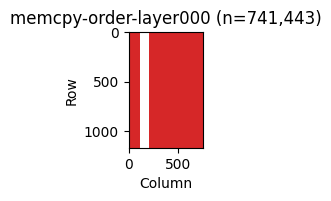

teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-red+dataset=memcpy-order-layer010+edgecolor=none+viz=scatterplot+x=y+y=x+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-red+dataset=memcpy-order-layer010+edgecolor=none+viz=scatterplot+x=y+y=x+ext=.png


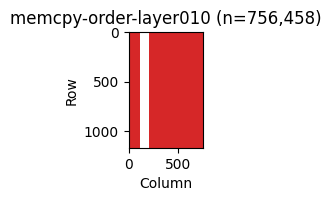

teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-red+dataset=channels+edgecolor=none+viz=scatterplot+x=y+y=x+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-red+dataset=channels+edgecolor=none+viz=scatterplot+x=y+y=x+ext=.png


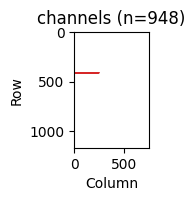

In [9]:
for name, df in dfs.items():
    with tp.teed(
        sns.scatterplot,
        data=df,
        x="y",
        y="x",
        s=1,
        alpha=0.4,
        color="tab:red",
        edgecolor="none",
        legend=False,
        teeplot_outattrs={"dataset": name},
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        ax.set_xlim(0, nCol)
        ax.set_ylim(nRow, 0)
        ax.set_aspect("equal")
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title(f"{name} (n={len(df):,})")
        ax.figure.set_size_inches(1.5, 1.5)


## Plot 2 --- Fault Proportion by Row


teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/hue=dataset+viz=lineplot+x=row+y=fault-proportion+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/hue=dataset+viz=lineplot+x=row+y=fault-proportion+ext=.png


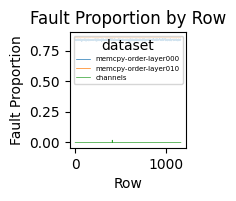

In [10]:
rows = []
for name, df in dfs.items():
    n_layers = df["layer"].nunique()
    faults_per_row = df.groupby("x").size()
    total_per_row = nCol * n_layers
    prop = (faults_per_row / total_per_row).reindex(
        range(nRow),
        fill_value=0,
    )
    row_df = pd.DataFrame({"row": prop.index, "fault_proportion": prop.values})
    row_df["dataset"] = name
    rows.append(row_df)

df_row_prop = pd.concat(rows, ignore_index=True)

with tp.teed(
    sns.lineplot,
    data=df_row_prop,
    x="row",
    y="fault_proportion",
    hue="dataset",
    linewidth=0.5,
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_xlabel("Row")
    ax.set_ylabel("Fault Proportion")
    ax.set_title("Fault Proportion by Row")
    sns.move_legend(ax, "upper right", fontsize=5)
    ax.figure.set_size_inches(1.5, 1.5)


## Plot 3 --- Fault Proportion by Column


teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/hue=dataset+viz=lineplot+x=column+y=fault-proportion+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/hue=dataset+viz=lineplot+x=column+y=fault-proportion+ext=.png


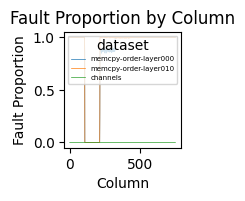

In [11]:
cols = []
for name, df in dfs.items():
    n_layers = df["layer"].nunique()
    faults_per_col = df.groupby("y").size()
    total_per_col = nRow * n_layers
    prop = (faults_per_col / total_per_col).reindex(
        range(nCol),
        fill_value=0,
    )
    col_df = pd.DataFrame(
        {"column": prop.index, "fault_proportion": prop.values}
    )
    col_df["dataset"] = name
    cols.append(col_df)

df_col_prop = pd.concat(cols, ignore_index=True)

with tp.teed(
    sns.lineplot,
    data=df_col_prop,
    x="column",
    y="fault_proportion",
    hue="dataset",
    linewidth=0.5,
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_xlabel("Column")
    ax.set_ylabel("Fault Proportion")
    ax.set_title("Fault Proportion by Column")
    sns.move_legend(ax, "upper right", fontsize=5)
    ax.figure.set_size_inches(1.5, 1.5)


## Plot 4 --- Temporal Distribution (channels)


teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/dataset=channels+edgecolor=none+hue=parity-error+multiple=stack+viz=histplot+weights=count+x=layer+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/dataset=channels+edgecolor=none+hue=parity-error+multiple=stack+viz=histplot+weights=count+x=layer+ext=.png


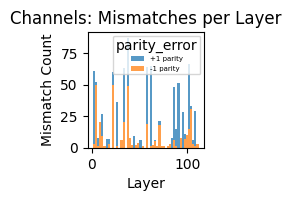

In [12]:
df_ch = dfs["channels"]
df_layer = (
    df_ch.groupby(["layer", "parity_error"]).size().reset_index(name="count")
)

with tp.teed(
    sns.histplot,
    data=df_layer,
    x="layer",
    hue="parity_error",
    weights="count",
    multiple="stack",
    bins=50,
    palette=["tab:blue", "tab:orange"],
    edgecolor="none",
    teeplot_outattrs={"dataset": "channels"},
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_xlabel("Layer")
    ax.set_ylabel("Mismatch Count")
    ax.set_title("Channels: Mismatches per Layer")
    sns.move_legend(ax, "upper right", fontsize=5)
    ax.figure.set_size_inches(1.5, 1.5)


## Plot 5 --- Parity Error Proportions Comparison


/tmp/ipykernel_4903/105539795.py:24: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/edgecolor=none+hue=parity-error+viz=barplot+x=dataset+y=proportion+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/edgecolor=none+hue=parity-error+viz=barplot+x=dataset+y=proportion+ext=.png


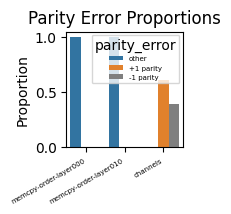

In [13]:
parity_rows = []
for name, df in dfs.items():
    counts = df["parity_error"].value_counts(normalize=True)
    for parity, prop in counts.items():
        parity_rows.append(
            {"dataset": name, "parity_error": parity, "proportion": prop}
        )

df_parity = pd.DataFrame(parity_rows)

with tp.teed(
    sns.barplot,
    data=df_parity,
    x="dataset",
    y="proportion",
    hue="parity_error",
    palette=["tab:blue", "tab:orange", "tab:gray"],
    edgecolor="none",
    teeplot_subdir=teeplot_subdir,
) as ax:
    ax.set_xlabel("")
    ax.set_ylabel("Proportion")
    ax.set_title("Parity Error Proportions")
    ax.set_xticklabels(
        ax.get_xticklabels(),
        rotation=30,
        ha="right",
        fontsize=5,
    )
    sns.move_legend(ax, "upper right", fontsize=5)
    ax.figure.set_size_inches(1.5, 1.5)


## Plot 6 --- Fault Proportion Heatmap (per dataset)


teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/cmap=ylorrd+dataset=memcpy-order-layer000+viz=heatmap+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/cmap=ylorrd+dataset=memcpy-order-layer000+viz=heatmap+ext=.png


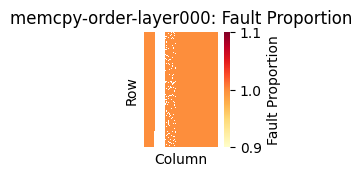

teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/cmap=ylorrd+dataset=memcpy-order-layer010+viz=heatmap+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/cmap=ylorrd+dataset=memcpy-order-layer010+viz=heatmap+ext=.png


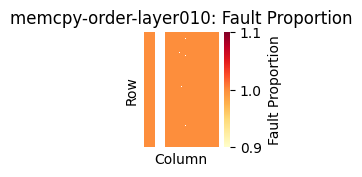

teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/cmap=ylorrd+dataset=channels+viz=heatmap+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/cmap=ylorrd+dataset=channels+viz=heatmap+ext=.png


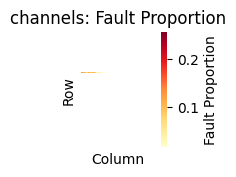

In [14]:
for name, df in dfs.items():
    n_layers = df["layer"].nunique()
    site_faults = df.groupby(["x", "y"]).size().reset_index(name="count")
    site_faults["proportion"] = site_faults["count"] / n_layers

    grid = np.full((nRow, nCol), np.nan)
    grid[
        site_faults["x"].values,
        site_faults["y"].values,
    ] = site_faults["proportion"].values

    with tp.teed(
        sns.heatmap,
        data=grid,
        cmap="YlOrRd",
        cbar_kws={"label": "Fault Proportion"},
        xticklabels=False,
        yticklabels=False,
        teeplot_outattrs={"dataset": name},
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        ax.set_xlabel("Column")
        ax.set_ylabel("Row")
        ax.set_title(f"{name}: Fault Proportion")
        ax.set_aspect("equal")
        ax.figure.set_size_inches(1.5, 1.5)


## Plot 7 --- Diff Value Distribution (memcpy-order)


/tmp/ipykernel_4903/2159563417.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-blue+dataset=memcpy-order-layer000+edgecolor=none+viz=countplot+x=diff-label+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-blue+dataset=memcpy-order-layer000+edgecolor=none+viz=countplot+x=diff-label+ext=.png


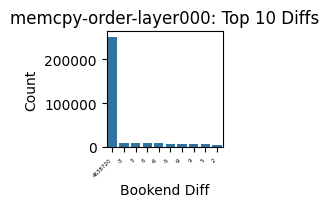

/tmp/ipykernel_4903/2159563417.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(


teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-blue+dataset=memcpy-order-layer010+edgecolor=none+viz=countplot+x=diff-label+ext=.pdf
teeplots/2026-03-24-d2h-memcpy-diagnostics-troubleshooting/color=tab-blue+dataset=memcpy-order-layer010+edgecolor=none+viz=countplot+x=diff-label+ext=.png


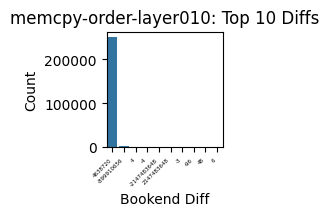

In [15]:
for name in ["memcpy-order-layer000", "memcpy-order-layer010"]:
    df = dfs[name]
    top_diffs = df["diff"].value_counts().head(10).index
    df_top = df[df["diff"].isin(top_diffs)].copy()
    df_top["diff_label"] = df_top["diff"].astype(str)

    with tp.teed(
        sns.countplot,
        data=df_top,
        x="diff_label",
        order=[str(d) for d in top_diffs],
        color="tab:blue",
        edgecolor="none",
        teeplot_outattrs={"dataset": name},
        teeplot_subdir=teeplot_subdir,
    ) as ax:
        ax.set_xlabel("Bookend Diff")
        ax.set_ylabel("Count")
        ax.set_title(f"{name}: Top 10 Diffs")
        ax.set_xticklabels(
            ax.get_xticklabels(),
            rotation=45,
            ha="right",
            fontsize=4,
        )
        ax.figure.set_size_inches(1.5, 1.5)
